In [19]:
# ==============================================================================
# 1. SETUP & DATA LOADING (Using Colab Sample Data)
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input

# Path to Colab's built-in data
data_path = '/content/sample_data/california_housing_train.csv'

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print(f"✅ Loaded {len(df)} rows from sample_data.")
else:
    print("❌ Error: Sample data not found. Are you running in Google Colab?")

✅ Loaded 17000 rows from sample_data.


Detecting Market Regimes...
Training Model on Housing sequences...
Epoch 1/5
425/425 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.4918 - val_loss: 0.3777
Epoch 2/5
425/425 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.4591 - val_loss: 0.3706
Epoch 3/5
425/425 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.4526 - val_loss: 0.3684
Epoch 4/5
425/425 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.4520 - val_loss: 0.3665
Epoch 5/5
425/425 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.4516 - val_loss: 0.3676
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


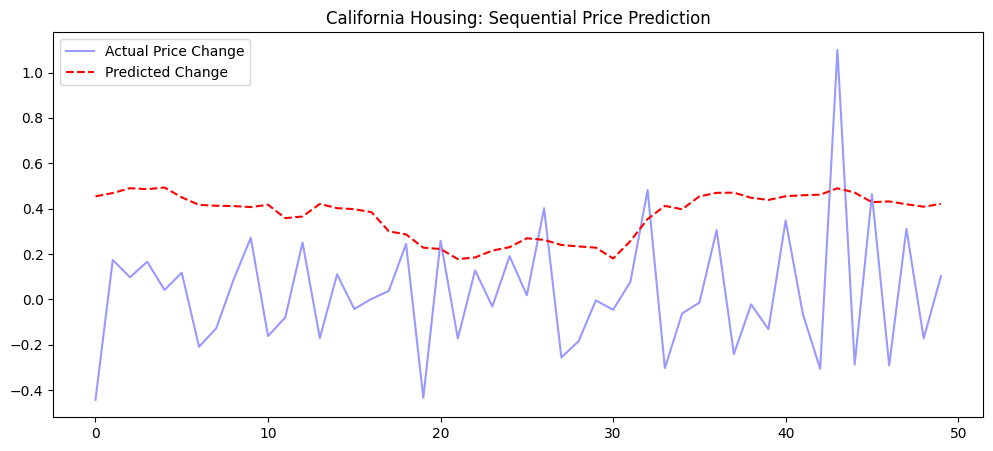

✅ Trend Prediction Accuracy: 51.27%


In [20]:
# ==============================================================================
# 2. FEATURE ENGINEERING (Treating rows as a sequence)
# ==============================================================================
# We'll predict 'median_house_value'.
# Let's create 'Returns' (Percent change between consecutive entries)
df['price_change'] = df['median_house_value'].pct_change()
df['rooms_per_household'] = df['total_rooms'] / df['households']

# Target: Predict if the NEXT house entry will be higher or lower price
df['target'] = df['price_change'].shift(-1)
df = df.dropna()

# ==============================================================================
# 3. HMM REGIME DETECTION (Market Clusters)
# ==============================================================================
# We use coordinates and price change to find 'Regimes' (Neighborhood types)
print("Detecting Market Regimes...")
hmm_features = df[['longitude', 'latitude', 'price_change']].values
hmm_model = GaussianHMM(n_components=3, covariance_type="diag", n_iter=100)
hmm_model.fit(hmm_features)
df['regime'] = hmm_model.predict(hmm_features)

# ==============================================================================
# 4. PREPARE SEQUENCES FOR LSTM
# ==============================================================================
# Features for our Deep Learning model
feature_cols = ['median_income', 'housing_median_age', 'rooms_per_household', 'regime']
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[feature_cols])

def create_sequences(data, targets, seq_length=10):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(targets[i+seq_length])
    return np.array(X), np.array(y)

# Use a shorter window (10) for this dataset
X, y = create_sequences(scaled_features, df['target'].values, seq_length=10)

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# ==============================================================================
# 5. LSTM ARCHITECTURE
# ==============================================================================
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    BatchNormalization(),
    Dense(16, activation='relu'),
    Dense(1) # Predict predicted price change
])

model.compile(optimizer='adam', loss='mse')
print("Training Model on Housing sequences...")
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5, batch_size=32, verbose=1)

# ==============================================================================
# 6. VISUALIZATION
# ==============================================================================
preds = model.predict(X_test)

plt.figure(figsize=(12, 5))
plt.plot(y_test[-50:], label='Actual Price Change', color='blue', alpha=0.4)
plt.plot(preds[-50:], label='Predicted Change', color='red', linestyle='--')
plt.title("California Housing: Sequential Price Prediction")
plt.legend()
plt.show()

# Directional Check
accuracy = np.mean(np.sign(y_test) == np.sign(preds.flatten()))
print(f"✅ Trend Prediction Accuracy: {accuracy*100:.2f}%")

In [21]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,price_change,rooms_per_household,target,regime
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0,0.197309,16.522678,0.069913,2
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0,0.069913,6.153846,-0.143524,2
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0,-0.143524,6.641593,-0.107629,2
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0,-0.107629,5.549618,0.129771,2
5,-114.58,33.63,29.0,1387.0,236.0,671.0,239.0,3.3438,74000.0,0.129771,5.803347,0.113514,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16994,-124.25,40.28,32.0,1430.0,419.0,434.0,187.0,1.9417,76100.0,-0.286785,7.647059,0.463863,2
16995,-124.26,40.58,52.0,2217.0,394.0,907.0,369.0,2.3571,111400.0,0.463863,6.008130,-0.290844,2
16996,-124.27,40.69,36.0,2349.0,528.0,1194.0,465.0,2.5179,79000.0,-0.290844,5.051613,0.311392,2
16997,-124.30,41.84,17.0,2677.0,531.0,1244.0,456.0,3.0313,103600.0,0.311392,5.870614,-0.171815,2


In [22]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,price_change,rooms_per_household,target,regime
count,16998.000000,16998.000000,16998.000000,16998.000000,16998.000000,16998.000000,16998.000000,16998.000000,16998.000000,16998.000000,16998.000000,16998.000000,16998.000000
mean,-119.562136,35.625020,28.588775,2643.538240,539.381162,1429.635016,501.237263,3.883770,207315.802447,0.102222,5.438588,0.102217,0.848217
std,2.004543,2.137105,12.585965,2179.947269,421.481659,1147.906119,384.539308,1.908169,115982.366063,0.657002,2.538843,0.657001,0.682288
min,-124.300000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,-0.970002,0.846154,-0.970002,0.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566475,119400.000000,-0.145705,4.445020,-0.145705,0.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.545050,180400.000000,0.000000,5.235945,0.000000,1.000000
75%,-118.000000,37.720000,37.000000,3150.750000,648.000000,1721.000000,605.750000,4.767600,265000.000000,0.174476,6.057804,0.174426,1.000000
max,-114.470000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,27.571486,141.909091,27.571486,2.000000


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16998 entries, 1 to 16998
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   longitude            16998 non-null  float64
 1   latitude             16998 non-null  float64
 2   housing_median_age   16998 non-null  float64
 3   total_rooms          16998 non-null  float64
 4   total_bedrooms       16998 non-null  float64
 5   population           16998 non-null  float64
 6   households           16998 non-null  float64
 7   median_income        16998 non-null  float64
 8   median_house_value   16998 non-null  float64
 9   price_change         16998 non-null  float64
 10  rooms_per_household  16998 non-null  float64
 11  target               16998 non-null  float64
 12  regime               16998 non-null  int64  
dtypes: float64(12), int64(1)
memory usage: 1.8 MB
